<a href="https://colab.research.google.com/github/dhiru69-tech/ML-Techniques-Lab-Project/blob/main/notebooks/day08_evaluation_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# --- Cell 1: Setup (same as Day 7) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load data. bad = 1 is the positive class we want to catch
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame
X = df.drop(columns=['class'])
y = df['class'].map({'good': 0, 'bad': 1}).astype(int)

# Stratified 80/20 split with a fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric columns and one-hot encode categorical columns (fit on train only)
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

preprocess = ColumnTransformer(
    [('num', StandardScaler(), num_cols),
     ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)],
    sparse_threshold=0
)
preprocess.set_output(transform="pandas")

X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)

print("Train:", X_train_p.shape, "| Test:", X_test_p.shape)
print("Bad customers in test set:", y_test.sum(), "out of", len(y_test))

Train: (800, 61) | Test: (200, 61)
Bad customers in test set: 60 out of 200


In [5]:
# --- Cell 2: Baseline ("always good") and its confusion matrix ---
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix

baseline = DummyClassifier(strategy='most_frequent')   # always predicts the majority class
baseline.fit(X_train_p, y_train)
pred_base = baseline.predict(X_test_p)

cm = confusion_matrix(y_test, pred_base)
print(cm)

# ravel() flattens the 2x2 table in this order: TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()
print("TN =", tn, "| FP =", fp, "| FN =", fn, "| TP =", tp)

[[140   0]
 [ 60   0]]
TN = 140 | FP = 0 | FN = 60 | TP = 0


In [6]:
# --- Cell 3: Metrics by hand ---
def metrics_from_counts(tn, fp, fn, tp):
    """Compute accuracy, precision, recall and F1 from confusion matrix counts."""
    total = tn + fp + fn + tp
    accuracy = (tp + tn) / total
    # Guard against division by zero when the model never predicts 'bad'
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1

acc, prec, rec, f1 = metrics_from_counts(tn, fp, fn, tp)
print(f"Baseline -> accuracy: {acc:.3f} | precision: {prec:.3f} | recall: {rec:.3f} | F1: {f1:.3f}")

Baseline -> accuracy: 0.700 | precision: 0.000 | recall: 0.000 | F1: 0.000


In [7]:
# --- Cell 4: Same metrics from sklearn (should match Cell 3) ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("accuracy :", round(accuracy_score(y_test, pred_base), 3))
print("precision:", round(precision_score(y_test, pred_base, zero_division=0), 3))
print("recall   :", round(recall_score(y_test, pred_base, zero_division=0), 3))
print("f1       :", round(f1_score(y_test, pred_base, zero_division=0), 3))

accuracy : 0.7
precision: 0.0
recall   : 0.0
f1       : 0.0


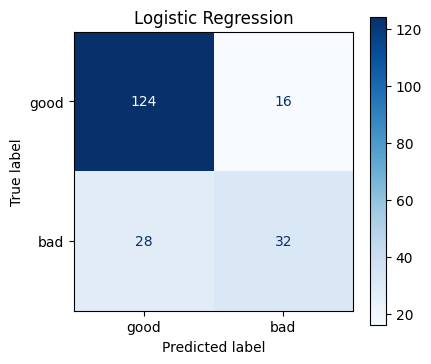

TN = 124 | FP = 16 | FN = 28 | TP = 32


In [8]:
# --- Cell 5: A real model (stand-in) and its confusion matrix ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_p, y_train)
pred = model.predict(X_test_p)

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=['good', 'bad'], cmap='Blues', ax=ax
)
plt.title("Logistic Regression")
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
print("TN =", tn, "| FP =", fp, "| FN =", fn, "| TP =", tp)

In [9]:
# --- Cell 6: Baseline vs real model, side by side ---
models_pred = {
    'baseline (always good)': pred_base,
    'logistic regression': pred,
}

compare = pd.DataFrame({
    name: {
        'accuracy': accuracy_score(y_test, p),
        'precision': precision_score(y_test, p, zero_division=0),
        'recall': recall_score(y_test, p, zero_division=0),
        'f1': f1_score(y_test, p, zero_division=0),
    }
    for name, p in models_pred.items()
}).T.round(3)

print(compare)

                        accuracy  precision  recall     f1
baseline (always good)      0.70      0.000   0.000  0.000
logistic regression         0.78      0.667   0.533  0.593
